In [1]:
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import math
import random
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
class Value:
    
    def __init__(self, data, _children = (), _op = "", label=""):
        self.data = data
        self._prev = (tuple(_children))
        self._op = _op
        self.label = label
        self.grad = 0.0

        self._backward = lambda: None
    
    def __repr__(self):
        return f"Value(data = {self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other

    def __neg__(self):
        return self * (-1)
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return other + (-self)
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting integer and float for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += out.grad * (other * (self.data**(other - 1)))
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other):
        return self * (other**-1)
    
    def __rtruediv__(self, other):
        return other * (self ** -1)
    
    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self, ), "ReLU")
        
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        import math
        t = (math.exp(2 * self.data) - 1) / (math.exp(2 * self.data) + 1)
        out = Value(t, (self, ), "tanh")
        def _backward():
            self.grad += (1 - (out.data**2)) * out.grad
        out._backward = _backward
        return out
    
    def exp(self):
        e = 2.718281828459045
        out = Value(e**self.data, (self, ), "exp")
        def _backward():
            self.grad += out.grad * out.data
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v: Value):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [4]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [19]:
# inputs / Axons
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label = "x2")
# weights / Synapses
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
# Bias
b = Value(6.8813735870195432, label="b")

# Dendrites
x1w1 = x1 * w1; x1w1.label="x1w1"
x2w2 = x2 * w2; x2w2.label = "x2w2"

# cell body
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
n = x1w1x2w2 + b; n.label = "n"

# Activation Function / Output neuron
o = n.tanh(); o.label="o"

o.backward()


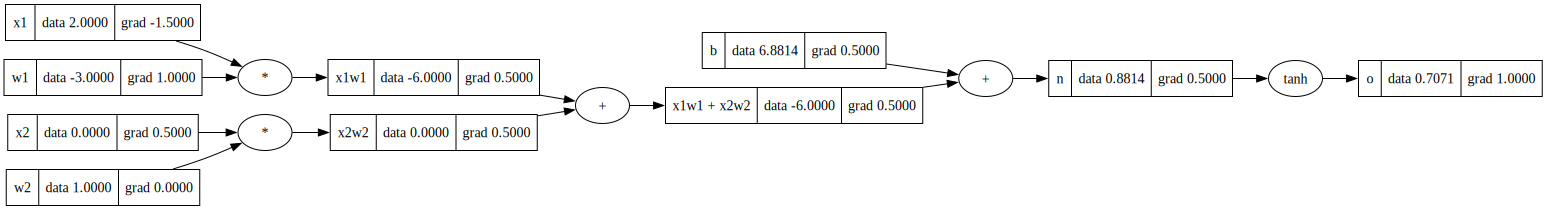

In [20]:
draw_dot(o)

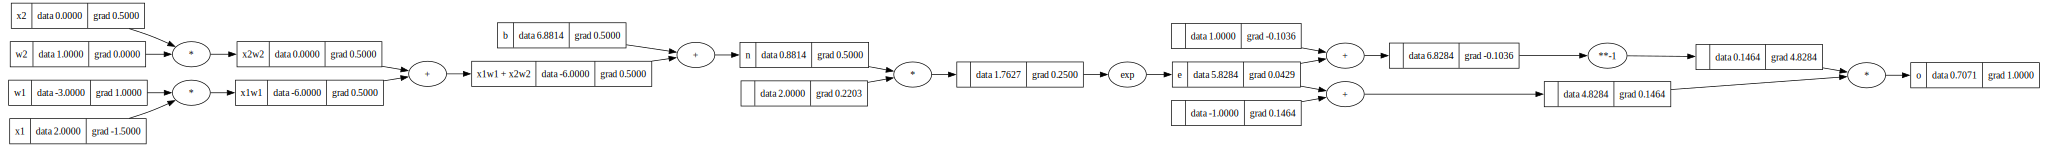

In [7]:
# inputs / Axons
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label = "x2")
# weights / Synapses
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
# Bias
b = Value(6.8813735870195432, label="b")

# Dendrites
x1w1 = x1 * w1; x1w1.label="x1w1"
x2w2 = x2 * w2; x2w2.label = "x2w2"

# cell body
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
n = x1w1x2w2 + b; n.label = "n"

# Activation Function / Output neuron
# ----
e = (2*n).exp(); e.label = "e"
o = (e - 1) / (e + 1)
# ----
o.label="o"
o.backward()
draw_dot(o)


In [8]:
import torch

In [9]:
x1 = torch.Tensor([2.0]).double()
x1.requires_grad = True

x2 = torch.Tensor([0.0]).double()
x2.requires_grad = True

w1 = torch.Tensor([-3.0])
w1.requires_grad = True

w2 = torch.Tensor([1.0])
w2.requires_grad = True

b = torch.Tensor([6.8813735870195432])
b.requires_grad = True

n = w1 * x1 + w2 * x2 + b
o = torch.tanh(n)
print(o.item())
o.backward()

print('---')
if x2.grad is not None:
    print('x2', x2.grad.item())
if w2.grad is not None:
    print('w2', w2.grad.item())
if x1.grad is not None:
    print('x1', x1.grad.item())
if w1.grad is not None:
    print('w1', w1.grad.item())
    


0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.000000238418579


In [10]:
class Neuron:
    def __init__(self, nin) -> None:
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        if(len(outs) == 1):return outs[0]
        else: return outs
    
    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params
    
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        params = []
        for layer in self.layers:
            ps = layer.parameters()
            params.extend(ps)
        return params

In [11]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data = -0.43683149494627616)

In [12]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [13]:
for k in range(20):
    # Forward Pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for yout, ygt in zip(ypred, ys))

    # Backward Pass 
    # 1. Most important step after each iteration set gradients of each parameters to 0.0 to avoid adding past gradient values
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # Update parameters
    for p in n.parameters():
        p.data += -0.05 * p.grad
    
    print(k, loss.data)


0 5.010320396394283
1 2.4908038118757982
2 1.8082813196958198
3 1.117689873150563
4 0.7193564585166918
5 0.2471397728040128
6 0.17725793639214377
7 0.14466680945435514
8 0.12141848310023336
9 0.10407527970508595
10 0.09072087199547327
11 0.08017073038696898
12 0.07165646597850323
13 0.06466063541009257
14 0.05882365014787981
15 0.05388877689426324
16 0.04966836592949631
17 0.046022414322227395
18 0.04284455711302279
19 0.04005267397215817


In [14]:
ypred

[Value(data = 0.9141208964287808),
 Value(data = -0.9488008180263222),
 Value(data = -0.8790956371081522),
 Value(data = 0.875749316537475)]